In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report, roc_auc_score
from tqdm import tqdm
import warnings
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

In [3]:
# Constants
SEED = 42
REPEATS = 5
FOLDS = 5

In [4]:
# Base directory
BASE_DIR = Path("../../data")
RAW_DIR = BASE_DIR / "raw" / "widsdatathon2025"
PROCESSED_DIR = BASE_DIR / "preprocessed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
# Load Training Data
train_fcm = pd.read_csv(RAW_DIR / "TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv")
train_solutions = pd.read_excel(RAW_DIR / "TRAIN/TRAINING_SOLUTIONS.xlsx")

# Load Test Data
test_fcm = pd.read_csv(RAW_DIR / "TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")

In [6]:
train_fcm.head()

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.093473,0.146902,0.067893,0.015141,0.070221,0.063997,0.055382,-0.035335,0.068583,...,0.003404,-0.010359,-0.050968,-0.014365,0.128066,0.112646,-0.058980,0.028228,0.133582,0.143372
1,WHWymJu6zNZi,0.029580,0.179323,0.112933,0.038291,0.104899,0.064250,0.008488,0.077505,-0.004750,...,-0.008409,-0.008479,0.020891,0.017754,0.094040,0.035141,0.032537,0.075007,0.115350,0.138200
2,4PAQp1M6EyAo,-0.051580,0.139734,0.068295,0.046991,0.111085,0.026978,0.151377,0.021198,0.083721,...,0.053245,-0.028003,0.028773,0.024556,0.166343,0.058925,0.035485,0.063661,0.042862,0.162162
3,obEacy4Of68I,0.016273,0.204702,0.115980,0.043103,0.056431,0.057615,0.055773,0.075030,0.001033,...,-0.023918,-0.005356,0.018607,0.016193,0.072955,0.130135,0.056120,0.084784,0.114148,0.190584
4,s7WzzDcmDOhF,0.065771,0.098714,0.097604,0.112988,0.071139,0.085607,0.019392,-0.036403,-0.020375,...,0.066439,-0.076680,-0.047530,-0.031443,0.221213,0.007343,0.005763,0.083820,0.079582,0.067269


Top 50 Connectome Features Correlated with ADHD Outcome:
164throw_189thcolumn    0.184340
164throw_173thcolumn    0.156365
158throw_191thcolumn    0.138679
28throw_188thcolumn     0.131621
131throw_198thcolumn    0.131566
133throw_182thcolumn    0.130450
183throw_189thcolumn    0.130260
114throw_121thcolumn    0.129459
172throw_188thcolumn    0.126670
180throw_182thcolumn    0.123855
71throw_73thcolumn      0.123207
160throw_190thcolumn    0.122821
183throw_197thcolumn    0.122806
73throw_133thcolumn     0.120701
89throw_91thcolumn      0.119434
185throw_191thcolumn    0.118625
75throw_86thcolumn      0.116833
67throw_132thcolumn     0.114221
90throw_183thcolumn     0.113679
183throw_196thcolumn    0.113501
104throw_135thcolumn    0.112353
70throw_149thcolumn     0.111334
74throw_184thcolumn     0.110904
131throw_193thcolumn    0.109732
71throw_138thcolumn     0.109564
91throw_93thcolumn      0.109490
43throw_166thcolumn     0.109253
42throw_199thcolumn     0.109066
34throw_65thcolumn 

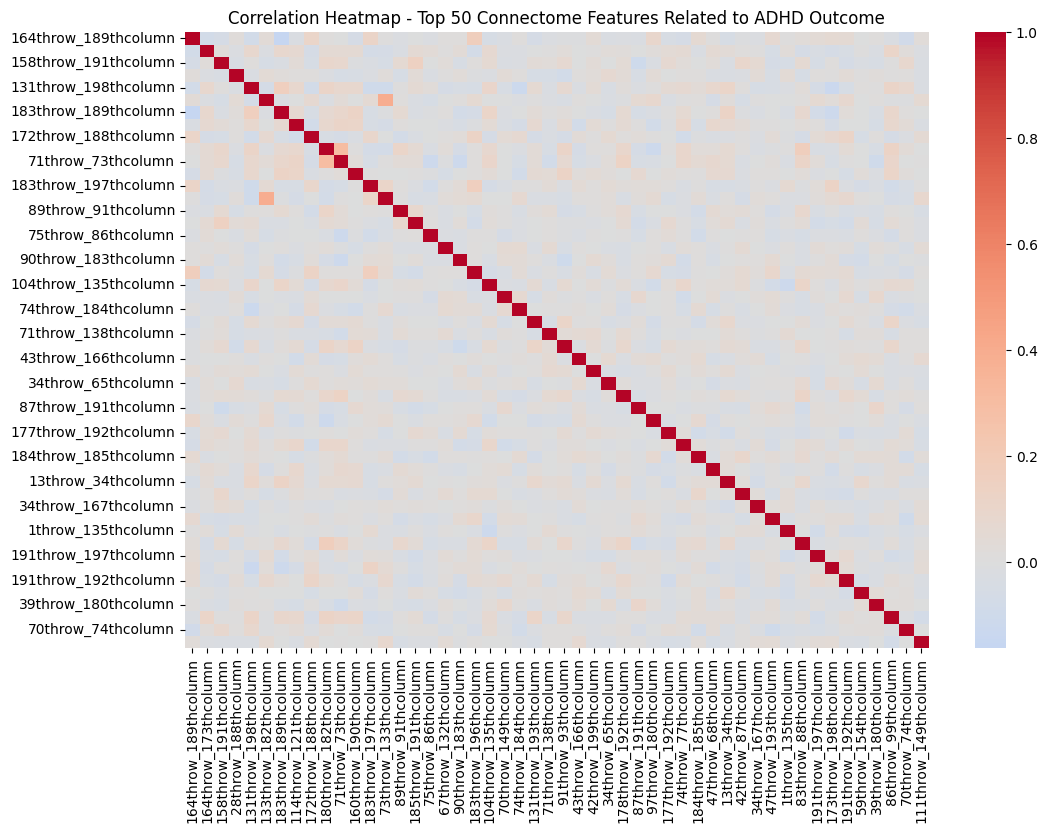

In [8]:
connectome_data = pd.concat([train_fcm, test_fcm], ignore_index=True)

# Columns of interest
participant_id_col = "participant_id"
sex_col = "Sex_F"

# Merge Sex_F with Connectome data
merged_df = pd.merge(train_solutions[[participant_id_col, sex_col]], connectome_data, on=participant_id_col, how="left")

# Drop non-numeric columns (except Sex_F)
numeric_cols = merged_df.select_dtypes(include=["number"]).columns
filtered_df = merged_df[numeric_cols]

# Compute correlation with Sex_F 
correlation_matrix = filtered_df.corr()[sex_col].drop(sex_col)  

# Get top 50 features most correlated with Sex_F 
top_50_features = correlation_matrix.abs().nlargest(50)

# Print top features
print("Top 50 Connectome Features Correlated with ADHD Outcome:")
print(top_50_features)

# Visualization: Heatmap for Top 50 Features
plt.figure(figsize=(12, 8))
sns.heatmap(filtered_df[top_50_features.index].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Top 50 Connectome Features Related to ADHD Outcome")
plt.show()

In [7]:
top_50_features = [
    "164throw_189thcolumn",
    "164throw_173thcolumn",
    "158throw_191thcolumn",
    "28throw_188thcolumn",
    "131throw_198thcolumn",
    "133throw_182thcolumn",
    "183throw_189thcolumn",
    "114throw_121thcolumn",
    "172throw_188thcolumn",
    "180throw_182thcolumn",
    "71throw_73thcolumn",
    "160throw_190thcolumn",
    "183throw_197thcolumn",
    "73throw_133thcolumn",
    "89throw_91thcolumn",
    "185throw_191thcolumn",
    "75throw_86thcolumn",
    "67throw_132thcolumn",
    "90throw_183thcolumn",
    "183throw_196thcolumn",
    "104throw_135thcolumn",
    "70throw_149thcolumn",
    "74throw_184thcolumn",
    "131throw_193thcolumn",
    "71throw_138thcolumn",
    "91throw_93thcolumn",
    "43throw_166thcolumn",
    "42throw_199thcolumn",
    "34throw_65thcolumn",
    "178throw_192thcolumn",
    "87throw_191thcolumn",
    "97throw_180thcolumn",
    "177throw_192thcolumn",
    "74throw_77thcolumn",
    "184throw_185thcolumn",
    "47throw_68thcolumn",
    "13throw_34thcolumn",
    "42throw_87thcolumn",
    "34throw_167thcolumn",
    "47throw_193thcolumn",
    "1throw_135thcolumn",
    "83throw_88thcolumn",
    "191throw_197thcolumn",
    "173throw_198thcolumn",
    "191throw_192thcolumn",
    "59throw_154thcolumn",
    "39throw_180thcolumn",
    "86throw_99thcolumn",
    "70throw_74thcolumn",
    "111throw_149thcolumn"
]

Model Accuracy: 0.7654
ROC-AUC Score: 0.8272

Classification Report:

F1 Score: 


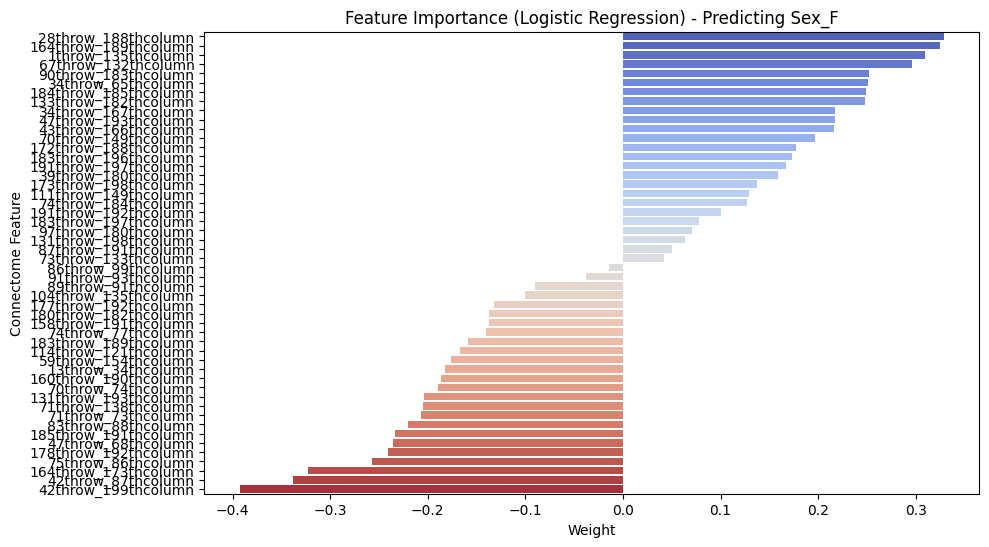

In [21]:
# Prepare features (X) - Only using Connectome data, no Sex_F
X = merged_df[top_50_features] 
y = merged_df[sex_col]  # Target (0 = Male, 1 = Female)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the data (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

print(f"Model Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")

# Feature Importance (Weights)
feature_importance = pd.DataFrame({"Feature": top_50_features, "Weight": model.coef_[0]})
feature_importance = feature_importance.sort_values(by="Weight", ascending=False)

# Visualization: Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance["Weight"], y=feature_importance["Feature"], palette="coolwarm")
plt.title("Feature Importance (Logistic Regression) - Predicting Sex_F")
plt.xlabel("Weight")
plt.ylabel("Connectome Feature")
plt.show()

In [19]:
# Columns of interest
participant_id_col = "participant_id"
sex_col = "Sex_F"

merged_df = pd.merge(train_solutions[[participant_id_col, sex_col]], train_fcm, on=participant_id_col, how="left")

# Prepare features (X) - Only using Connectome data, no Sex_F
X = merged_df[top_50_features] 
y = merged_df[sex_col]  # Target (0 = Male, 1 = Female)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Sex Model
model_sex = XGBClassifier(
        n_estimators=500,  
        learning_rate=0.03,  
        max_depth=8, 
        colsample_bytree=0.8,
        subsample=0.8,
        gamma=1, 
        reg_lambda=10,  
        reg_alpha=1, 
        random_state=42
    )

# Cross-Validation for Sex
cv_sex = RepeatedStratifiedKFold(n_splits=FOLDS, n_repeats=REPEATS, random_state=SEED)
sex_scores = []

# Loop through cross-validation splits (tqdm just shows progress)
for train_idx, val_idx in tqdm(cv_sex.split(X, y), total=FOLDS*REPEATS):
    
    # Split dataset into training + validation sets using the indices generated by cross-validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train the ADHD model using only the selected feature subset
    model_sex.fit(X_train[top_50_features], y_train)
    
    # Generate predictions on the validation set
    y_pred = model_sex.predict(X_val[top_50_features])
    # Compute the F1-score for the current fold and append it to the results list
    sex_scores.append(f1_score(y_val, y_pred))

print(f"Sex F1 Score: {np.mean(sex_scores):.4f} ± {np.std(sex_scores):.4f}")

100%|██████████| 25/25 [00:42<00:00,  1.69s/it]

Sex F1 Score: 0.5543 ± 0.0546


In [22]:
# Train final models on entire training data
model_sex.fit(train_fcm[top_50_features], y)

# Predict on test data
test_fcm['sex_proba'] = model_sex.predict(test_fcm[top_50_features])[:, 1]

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
# Convert probabilities to binary predictions
sex_threshold = 0.3
test_fcm['Sex_F'] = (test_fcm['sex_proba'] >= sex_threshold).astype(int)
